# Plot Results for the Random Gx/Gx/c Queue Generator

This script generates plots and visual analyses for simulations produced by the random **Gx/Gx/c** queue generator.

### Requirements
- `exp_ggc`

### Authors
- Rafael Andrade  
- Eriky Silva  
- Frederico Cruz  

---

Required packages

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import pickle
from PIL import Image

### Prepare data for plotting

In [2]:
filename = "sim_2026-05-08.pkl"

with open(filename, 'rb') as f:
    results = pickle.load(f)

df_mxm1 = results['sim_MxM1']
df_mmx1 = results['sim_MMx1']
df_mmc = results['sim_MMc']

In [3]:
df_mxm1.head(10)

,lambda,mu,tmax,Wq_mean,Lq_mean,Rho_mean,Wq_var,Lq_var,Rho_var,batch
0,1.0,10.0,100,0.011074,0.011254,0.100020,3.203207e-05,3.679873e-05,0.000188,1
1,1.0,10.0,500,0.011634,0.011721,0.100809,7.402069e-06,8.144968e-06,0.000039,1
2,1.0,10.0,1000,0.011380,0.011448,0.100607,3.593359e-06,4.086892e-06,0.000019,1
3,1.0,10.0,2000,0.011109,0.011129,0.100024,2.423911e-06,2.751139e-06,0.000010,1
4,1.0,10.0,5000,0.011105,0.011088,0.099663,7.036516e-07,7.717203e-07,0.000004,1
5,1.0,10.0,10000,0.011057,0.011047,0.099889,3.059742e-07,3.694211e-07,0.000002,1
6,1.0,10.0,15000,0.011051,0.011047,0.099928,2.252712e-07,2.536835e-07,0.000001,1
7,1.0,10.0,20000,0.011019,0.011011,0.099790,1.557168e-07,1.792334e-07,0.000001,1
8,1.0,5.0,100,0.049788,0.050791,0.201167,4.859965e-04,6.331859e-04,0.000830,1
9,1.0,5.0,500,0.050038,0.050285,0.200351,1.228207e-04,1.449822e-04,0.000170,1


### Plotting batch effect
---

#### Plotting design

In [4]:
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "font.size": 12,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.2,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "legend.frameon": False,
})

#COLORS = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
COLORS = ["#1F3B73", "#A64B2A", "#2F6B4F", "#6B4C9A"]
MARKERS = ["o", "s", "^", "D"]
LINESTYLES = ["-", "--", "-.", ":"]

In [12]:
def plot_metric(df, x, y, xlabel, ylabel, filename ="plot.png"):

    df = df[df["tmax"] == df["tmax"].max()] # filter the best estimates
    _, ax = plt.subplots()

    for i, ((lmb, mu), g) in enumerate(df.groupby(["lambda", "mu"])):

        ax.plot(
            g[x],
            g[y],
            color=COLORS[i % len(COLORS)],
            marker=MARKERS[i % len(MARKERS)],
            linestyle=LINESTYLES[i % len(LINESTYLES)],
            linewidth=2,
            label=rf"$\lambda/\mu = {lmb/mu:.2f}$"
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks(g[x].unique())

    ax.legend()
    plt.tight_layout()
    plt.savefig(filename, bbox_inches="tight")
    Image.open(filename).save(filename.replace(".png", ".gif"))
    #plt.show()


#### Mx/M/1

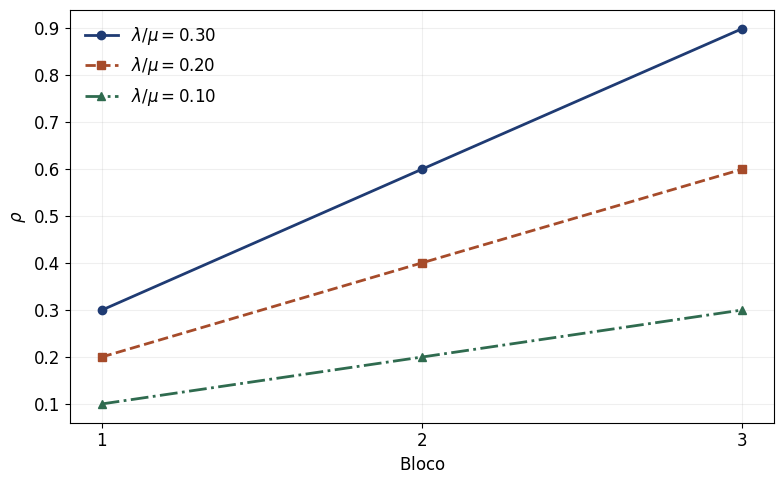

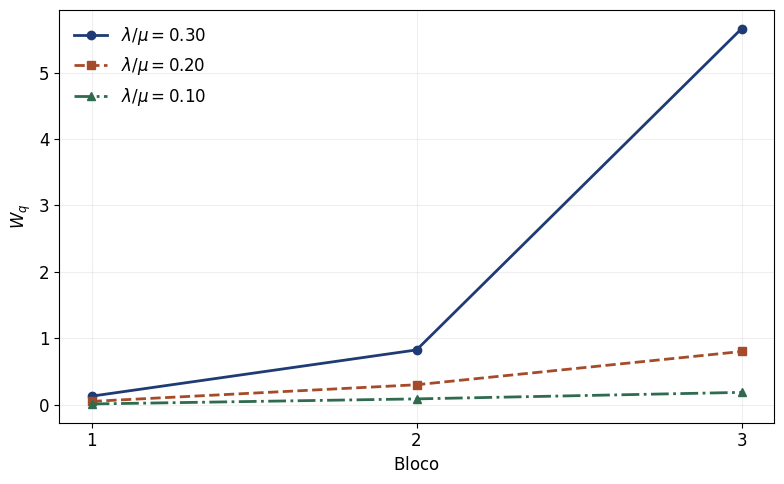

In [14]:
plot_metric(df_mxm1,"batch", "Rho_mean", r"$\mathrm{Bloco}$", r"$\rho$", filename="rho_mxm1.png")
plot_metric(df_mxm1, "batch","Wq_mean", r"$\mathrm{Bloco}$", r"$W_q$", filename="wq_mxm1.png")

#### M/Mx/1

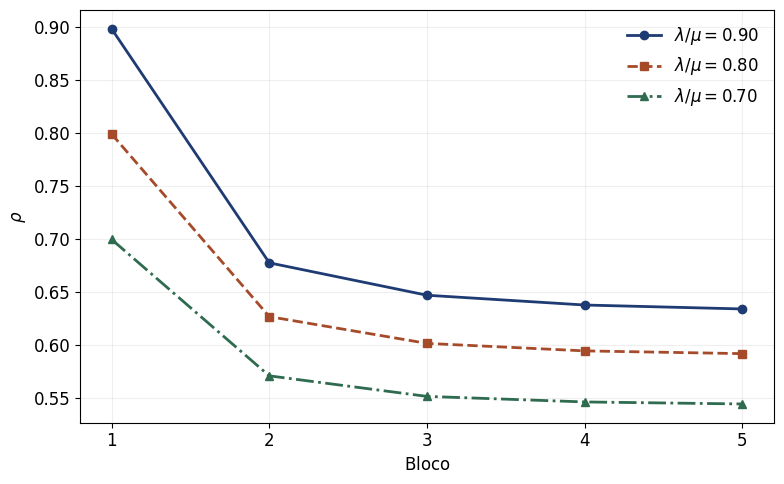

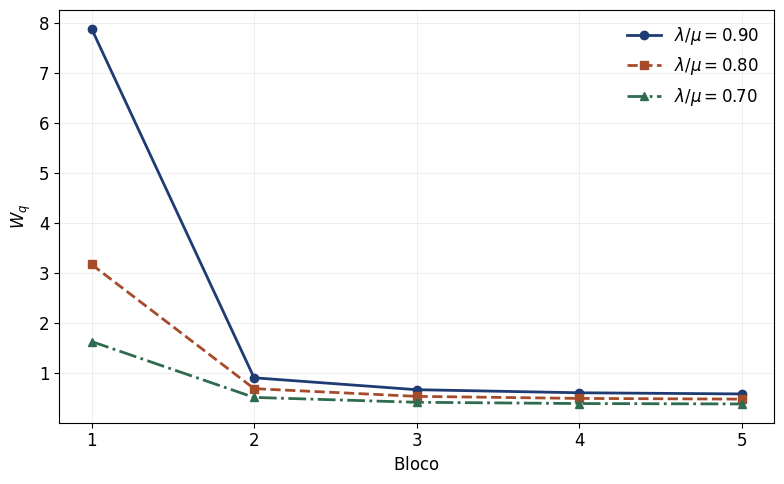

In [15]:
plot_metric(df_mmx1,"batch", "Rho_mean", r"$\mathrm{Bloco}$", r"$\rho$", filename="rho_mmx1.png")
plot_metric(df_mmx1, "batch","Wq_mean", r"$\mathrm{Bloco}$", r"$W_q$", filename="wq_mmx1.png")

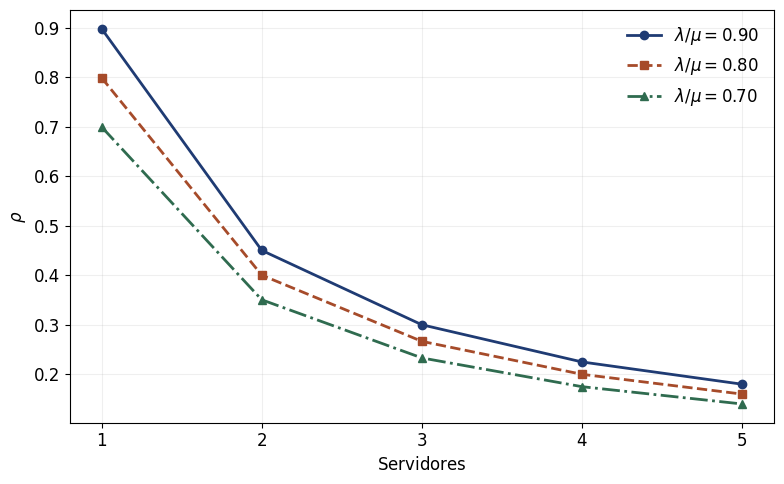

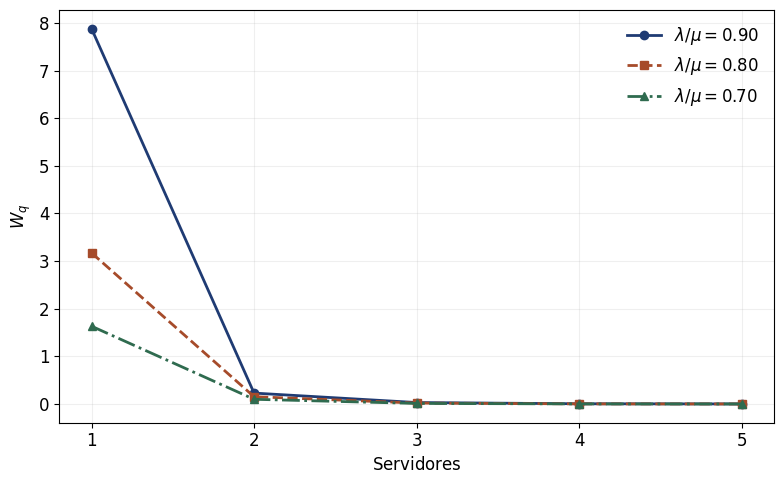

In [16]:
plot_metric(df_mmc, "nserv", "Rho_mean", r"$\mathrm{Servidores}$", r"$\rho$", filename="rho_mmc.png")
plot_metric(df_mmc, "nserv","Wq_mean", r"$\mathrm{Servidores}$", r"$W_q$")

### Plotting convergence
---

In [20]:
def plot_convergence(df, y, ylabel, filename="convergence.png"):

    _, ax = plt.subplots()

    for i, ((lmb, mu), g) in enumerate(df.groupby(["lambda", "mu"])):

        g = g.sort_values("tmax")

        ax.plot(
            g["tmax"],
            g[y],
            color=COLORS[i % len(COLORS)],
            marker=MARKERS[i % len(MARKERS)],
            linestyle=LINESTYLES[i % len(LINESTYLES)],
            linewidth=2,
            label=rf"$\lambda/\mu = {lmb/mu:.2f}$"
        )

    ax.set_xlabel(r"$t_{\max}$")
    ax.set_ylabel(ylabel)

    #ax.set_xticks(sorted(df["tmax"].unique()))
    ax.set_ylim(0, df[y].max() * 1.4)
    
    ax.legend()

    plt.tight_layout()
    plt.savefig(filename)
    Image.open(filename).save(filename.replace(".png", ".gif"))
    #plt.show()

Mx/M/1

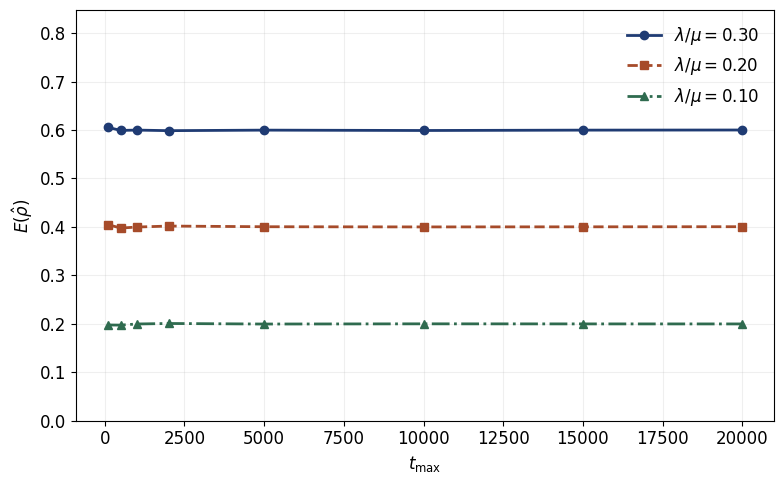

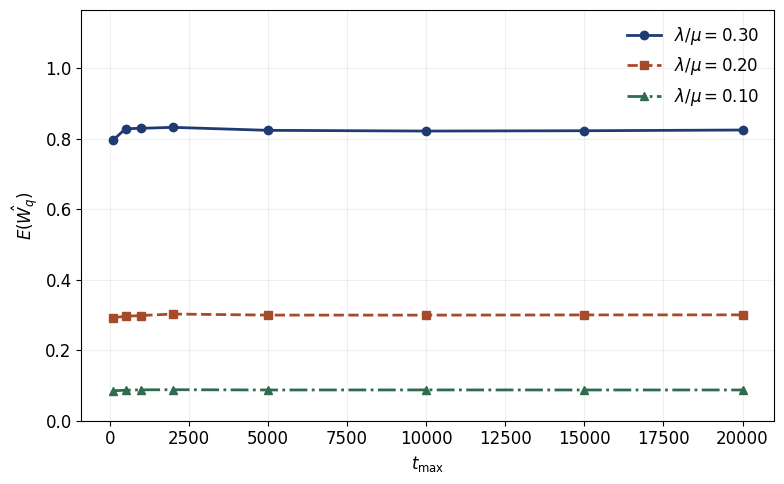

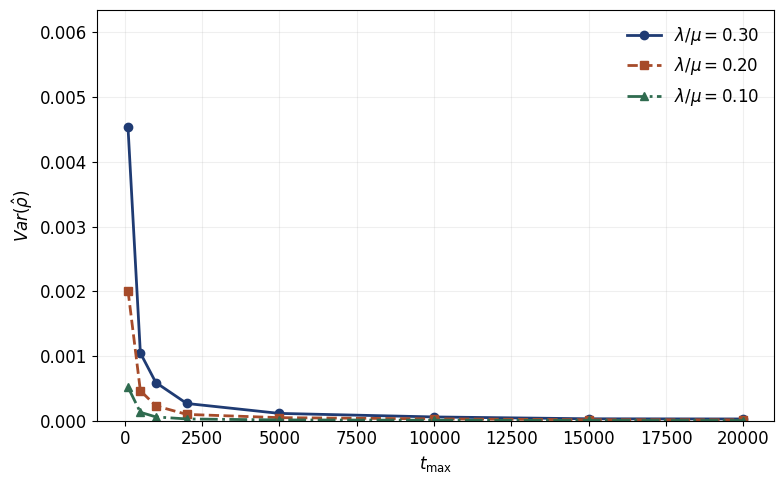

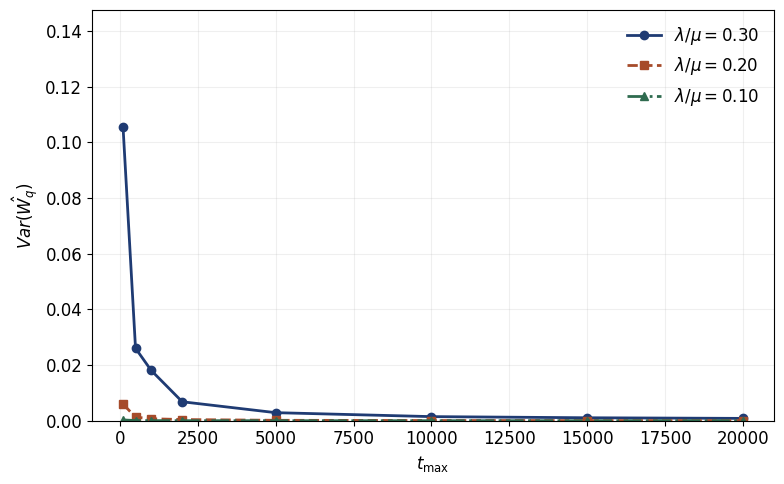

In [21]:
batch_conv = 2
plot_convergence(df_mxm1[df_mxm1["batch"] == batch_conv], "Rho_mean", r"$E(\hat{\rho})$", filename="rho_convergence.png")
plot_convergence(df_mxm1[df_mxm1["batch"] == batch_conv], "Wq_mean", r"$E(\hat{W_q})$", filename="wq_convergence.png")
plot_convergence(df_mxm1[df_mxm1["batch"] == batch_conv], "Rho_var", r"$Var(\hat{\rho})$", filename="rho_var_convergence.png")
plot_convergence(df_mxm1[df_mxm1["batch"] == batch_conv], "Wq_var", r"$Var(\hat{W_q})$", filename="wq_var_convergence.png")


M/Mx/1

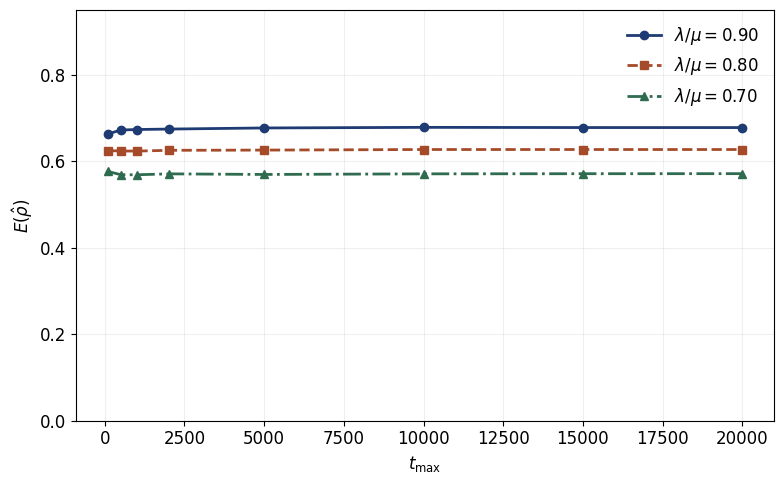

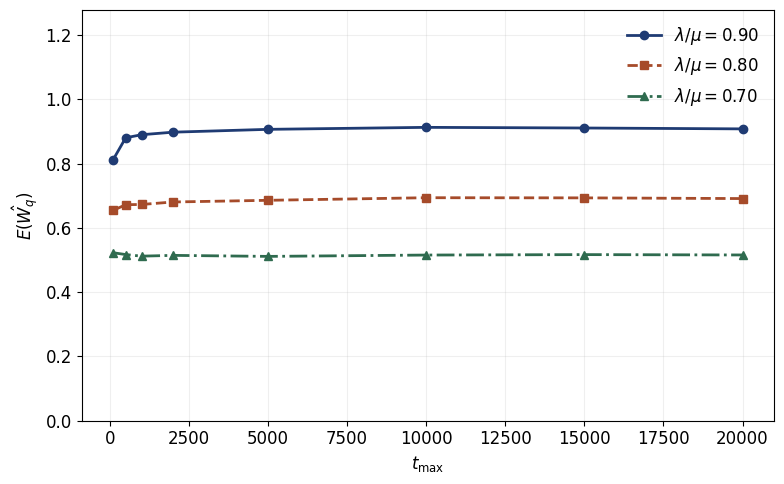

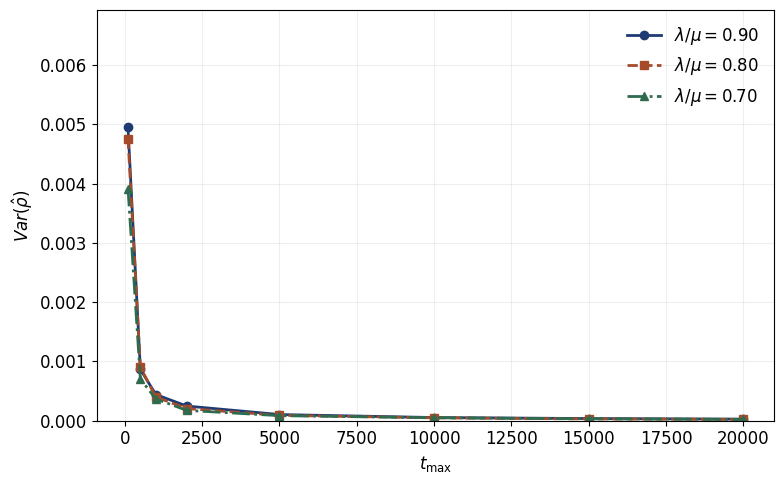

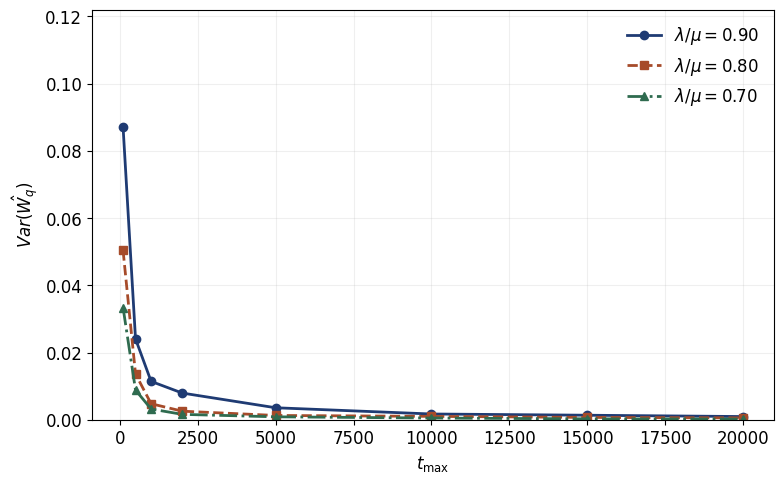

In [22]:
batch_conv = 2
plot_convergence(df_mmx1[df_mmx1["batch"] == batch_conv], "Rho_mean", r"$E(\hat{\rho})$", filename="rho_convergence_mmx1.png")
plot_convergence(df_mmx1[df_mmx1["batch"] == batch_conv], "Wq_mean", r"$E(\hat{W_q})$", filename="wq_convergence_mmx1.png")
plot_convergence(df_mmx1[df_mmx1["batch"] == batch_conv], "Rho_var", r"$Var(\hat{\rho})$", filename="rho_var_convergence_mmx1.png")
plot_convergence(df_mmx1[df_mmx1["batch"] == batch_conv], "Wq_var", r"$Var(\hat{W_q})$", filename="wq_var_convergence_mmx1.png")
